In [3]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import make_moons
from sklearn.preprocessing import OneHotEncoder
import torch.nn.functional as F

In [4]:
class BIMT(nn.Module):
    def __init__(self, layer_sizes, A, y_star, lambda_, k, S, alpha=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, verbose=False):
        """
        Initialises a BIMT neural network. The network consists of a number of layers, each with a number of neurons. The
        neurons are placed on a grid, where the x-coordinate is the layer number and the y-coordinate is the neuron
        number. The x-seperation between neurons is A and the y-seperation is y_star. The neurons are placed in the
        middle of the grid cells. The network is trained using the ADAM optimizer. The loss function is the cross entropy
        loss plus a regularisation term. The regularisation term is the sum of the absolute values of the weights and
        biases multiplied by the distance between the neurons. The distance between two neurons is the sum of the
        x-distance and the y-distance. The x-distance is the absolute value of the difference in x-coordinates
        multiplied by A. The y-distance is the absolute value of the difference in y-coordinates multiplied by y_star.
        The neurons are swapped every S steps. The k most important neurons are swapped. The importance of a neuron is
        the change in loss if the neuron is swapped with another neuron. The change in loss is the loss of the network
        after the swap minus the loss of the network before the swap. 

        :param layer_sizes: A list of the number of neurons in each layer.
        :param A: The x-seperation between neurons.
        :param y_star: The y-seperation between neurons.
        :param lambda_: The regularisation parameter.
        :param k: The number of important neurons to calculate potential swaps.
        :param S: The number of steps between swaps.
        :param alpha: The learning rate.
        :param beta1: The beta1 parameter of the ADAM optimizer.
        :param beta2: The beta2 parameter of the ADAM optimizer.
        :param epsilon: The epsilon parameter of the ADAM optimizer.
        :param verbose: To print or not to print? That is the question.

        :return: None.
        """
        
        super(BIMT, self).__init__()
        self.layer_sizes = layer_sizes
        self.A = A
        self.y_star = y_star
        self.lambda_ = lambda_
        self.k = k
        self.S = S
        self.steps = 1
        self.alpha = alpha
        self.store_loss = 0
        self.weight_loss = 0
        self.bias_loss = 0
        self.pred_loss = 0
        
        max_neurons = max(layer_sizes)
        self.positions = []
        for i, n in enumerate(layer_sizes):
            self.positions.append([(A * (0.5 + (j - n / 2) / max_neurons), i * y_star) for j in range(n)])

        self.distances = {}
        for i in range(len(layer_sizes) - 1):
            for j in range(layer_sizes[i]):
                for k in range(layer_sizes[i + 1]):
                    self.distances[(i, j, i + 1, k)] = self.distance(i, j, i + 1, k)

        self.layers = nn.ModuleList([nn.Linear(n_in, n_out) for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:])])

        self.optimizer = torch.optim.Adam(self.parameters(), lr=alpha, betas=(beta1, beta2), eps=epsilon)
        self.verbose = verbose

    def distance(self, i1, j1, i2, j2):
        """
        Computes the distance between two neurons.

        :param i1: The layer of the first neuron.
        :param j1: The index of the first neuron.
        :param i2: The layer of the second neuron.
        :param j2: The index of the second neuron.

        :return: The L1-distance between the two neurons.
        """
        pos1 = self.positions[i1][j1]
        pos2 = self.positions[i2][j2]
        return self.A*np.abs(pos1[0]-pos2[0]) + self.y_star

    def forward(self, x):
        """
        Performs a forward pass of the neural network.

        :param x: The input.

        :return: The output.
        """

        for layer in self.layers:
            x = F.silu(layer(x))
        return x

    def loss(self, y_pred, y_true):
        """
        Computes the loss of the neural network as the cross entropy loss plus a regularisation term 
        weighted by the regularisation parameter lambda_.

        :param y_pred: The predicted output.
        :param y_true: The true output.

        :return: The loss.
        """

        pred_loss = F.cross_entropy(y_pred, y_true)
        weight_loss = sum(torch.sum(torch.abs(w.weight) * self.distances[(i, j, i + 1, k)]) for i, w in enumerate(self.layers) for j in range(w.weight.shape[1]) for k in range(w.weight.shape[0]))
        bias_loss = sum(torch.sum(torch.abs(b.bias)) * self.y_star for b in self.layers)
        self.weight_loss = weight_loss
        self.bias_loss = bias_loss
        self.pred_loss = pred_loss
        if self.verbose:
            print(f"pred_loss: {pred_loss}, weight_loss: {weight_loss}, bias_loss: {bias_loss}, full_loss: {pred_loss + self.lambda_ * (weight_loss + bias_loss)}")
        return pred_loss + self.lambda_ * (weight_loss + bias_loss)
        return pred_loss

    def accuracy(self, X, y_true):
        """
        Computes the accuracy of the neural network.

        :param X: The input.
        :param y_true: The true output.

        :return: The accuracy.
        """

        y_pred = self.forward(X)
        return (y_pred.argmax(dim=1) == y_true.argmax(dim=1)).float().mean()
    
    def create_new_network(self):
        """
        Creates a new network with the same parameters as the current network.

        :return: The new network.
        """

        BIMT_copy = BIMT(self.layer_sizes, self.A, self.y_star, self.lambda_, self.k, self.S, self.alpha)
        BIMT_copy.load_state_dict(self.state_dict())
        return BIMT_copy
    
    def swap_neurons(self, i, j, k):
        """
        Swaps two neurons.

        :param i: The layer of the neurons.
        :param j: The index of the first neuron.
        :param k: The index of the second neuron.

        :return: None.
        """
        new_network = self.create_new_network()

        with torch.no_grad():
            if i == 0:
                new_network.layers[0].weight[:, j], new_network.layers[0].weight[:, k] = new_network.layers[0].weight[:, k].clone(), new_network.layers[0].weight[:, j].clone()
            elif 1 <= i < len(self.layer_sizes) - 1:
                if self.verbose:
                    print(new_network.layers[i].weight[j, :])
                new_network.layers[i-1].weight[j, :], new_network.layers[i-1].weight[k, :] = new_network.layers[i-1].weight[k, :].clone(), new_network.layers[i-1].weight[j, :].clone()
                new_network.layers[i].weight[:, j], new_network.layers[i].weight[:, k] = new_network.layers[i].weight[:, k].clone(), new_network.layers[i].weight[:, j].clone()
                if self.verbose:
                    print(new_network.layers[i].weight[k, :])
            else:
                new_network.layers[-1].weight[j, :], new_network.layers[-1].weight[k, :] = new_network.layers[-1].weight[k, :].clone(), new_network.layers[-1].weight[j, :].clone()
        return new_network

    def swap(self):
        """
        Computes the scores of all neurons and swaps the k most important neurons.
    
        :return: None.
        """
        if self.steps % self.S != 0:
            return
        for i, n in enumerate(self.layer_sizes[:-1]):
            if i == 0:  # input layer
                scores = torch.sum(torch.abs(self.layers[0].weight), dim=0)
            elif i == len(self.layers) - 1:  # output layer
                scores = torch.sum(torch.abs(self.layers[-1].weight), dim=1)
            else:  # middle layers
                scores = torch.sum(torch.abs(self.layers[i-1].weight), dim=1) + torch.sum(torch.abs(self.layers[i].weight), dim=0)
            if self.verbose:
                print(f"Layer {i}:")
                print(f"Scores: {scores}")

            k = min(self.k, len(scores))  # adjust k to be no larger than the number of neurons in the layer
            important_neurons = torch.topk(scores, k).indices
            for neuron_index in important_neurons:
                if self.verbose:
                    print(f"Neuron {neuron_index}:")
                best_swap = torch.argmin(torch.tensor([self.loss_change_if_swapped(i, neuron_index.item(), k) for k in range(n)]))
                new_network = self.swap_neurons(i, neuron_index.item(), best_swap.item())
                self.update_weights_and_biases(new_network)

    def loss_change_if_swapped(self, i, j, k):
        """
        Computes the change in loss if two neurons are swapped.

        :param i: The layer of the neurons.
        :param j: The index of the first neuron.
        :param k: The index of the second neuron.

        :return: The change in loss.
        """

        # Create a new network and manually copy the weights and biases
        temp_net = self.create_new_network()
        # Swap the neurons in the temporary network
        temp_net.swap_neurons(i, j, k)

        # Compute the loss of the temporary network
        new_loss = temp_net.loss(temp_net.forward(self.X_train), self.y_train)

        # Compute the change in loss
        loss_change = new_loss - self.store_loss
        if self.verbose:
            print(f"Loss change: {loss_change}")
        return loss_change

    def update_weights_and_biases(self, new_network):
        """
        Updates the weights and biases of the current network with the weights and biases from a new network.
    
        :param new_network: The new network.
    
        :return: None.
        """
        with torch.no_grad():
            for old_layer, new_layer in zip(self.layers, new_network.layers):
                old_layer.weight.data = new_layer.weight.data.clone()
                old_layer.bias.data = new_layer.bias.data.clone()
    
    def train_step(self, x, y):
        """
        Performs a training step of the neural network using the ADAM optimizer.
    
        :param x: The input.
        :param y: The target.
    
        :return: None.
        """

        self.X_train = x
        self.y_train = y

        # Forward pass
        y_pred = self.forward(x)
    
        # Compute loss
        loss = self.loss(y_pred, y)

        self.store_loss = loss
        # Backward pass
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
    
        # Perform neuron swapping if necessary
        if self.steps % self.S == 0:
            self.swap()
    
        self.steps += 1

In [7]:
X, y = make_moons(n_samples=1000, noise=0.1)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

# One-hot encode the labels
encoder = OneHotEncoder(sparse=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))
y_onehot = torch.from_numpy(y_onehot).float()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Initialize the BIMT network
net = BIMT(layer_sizes=[2, 20, 20, 2], A=2, y_star=0.1, lambda_=0.001, k=6, S=200, alpha=0.001)

/Users/maxpowers/miniconda3/envs/DL/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


--------------------------------------------------
Epoch: 0
Loss: 0.7215524315834045
Weight Loss: 28.604509353637695
Bias Loss: 0.8626514673233032
Running Loss: 2582.743896484375
Accuracy: 0.4399999976158142
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

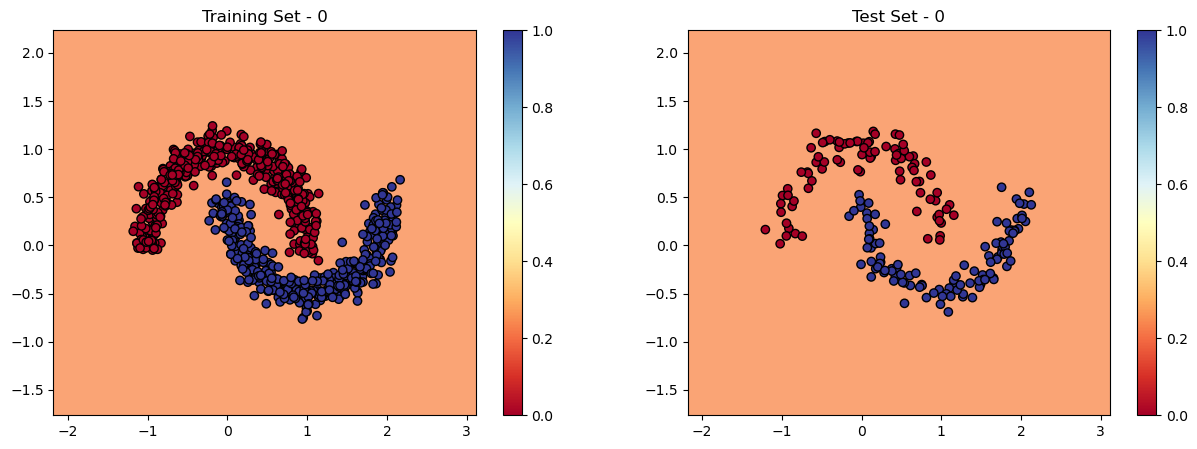

--------------------------------------------------
Epoch: 1
Loss: 0.7076835632324219
Weight Loss: 25.442054748535156
Bias Loss: 0.5176349878311157
Running Loss: 575.6621704101562
Accuracy: 0.4399999976158142
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

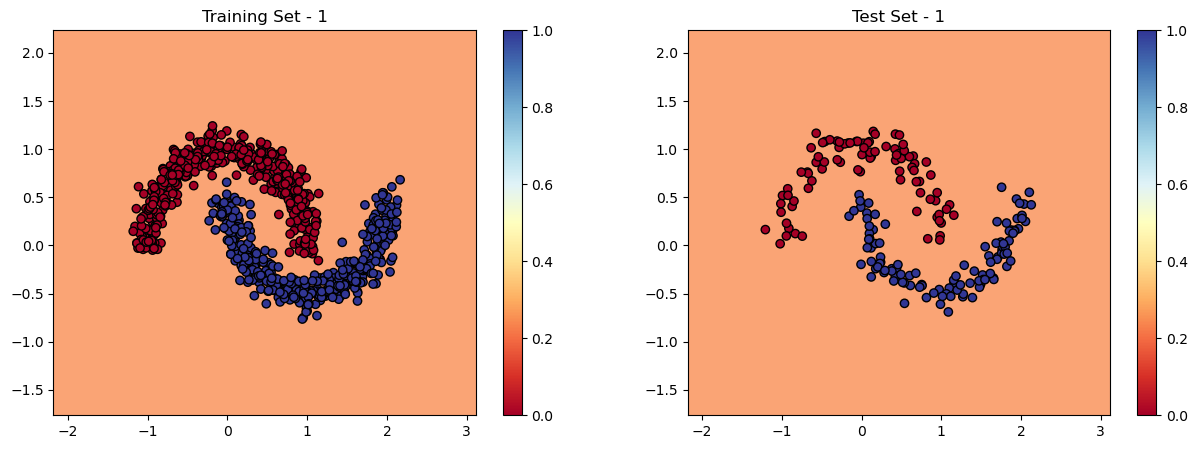

--------------------------------------------------
Epoch: 2
Loss: 0.6996526718139648
Weight Loss: 24.10248565673828
Bias Loss: 0.31352025270462036
Running Loss: 574.9496459960938
Accuracy: 0.4399999976158142
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

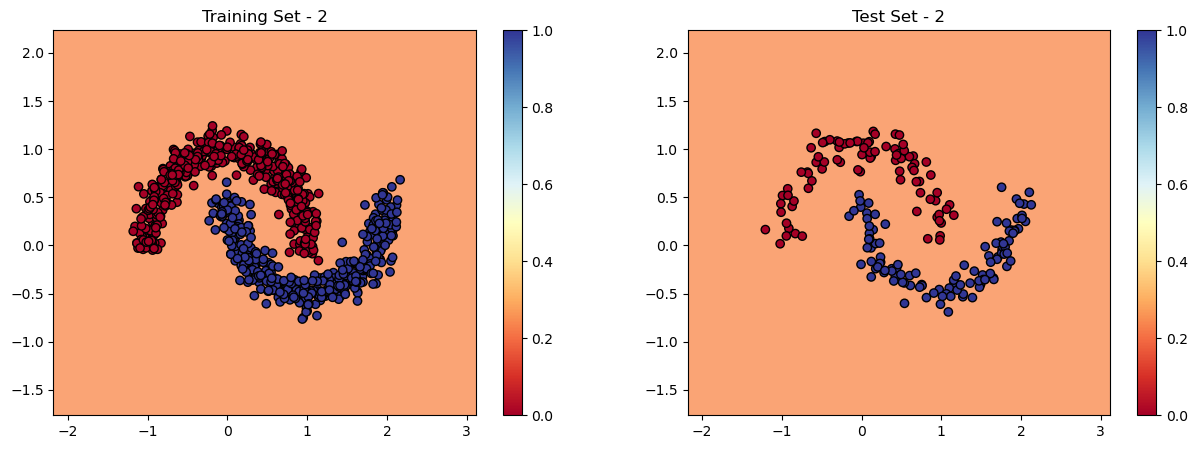

--------------------------------------------------
Epoch: 3
Loss: 0.6954753994941711
Weight Loss: 23.989166259765625
Bias Loss: 0.17774249613285065
Running Loss: 574.8951416015625
Accuracy: 0.4399999976158142
[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

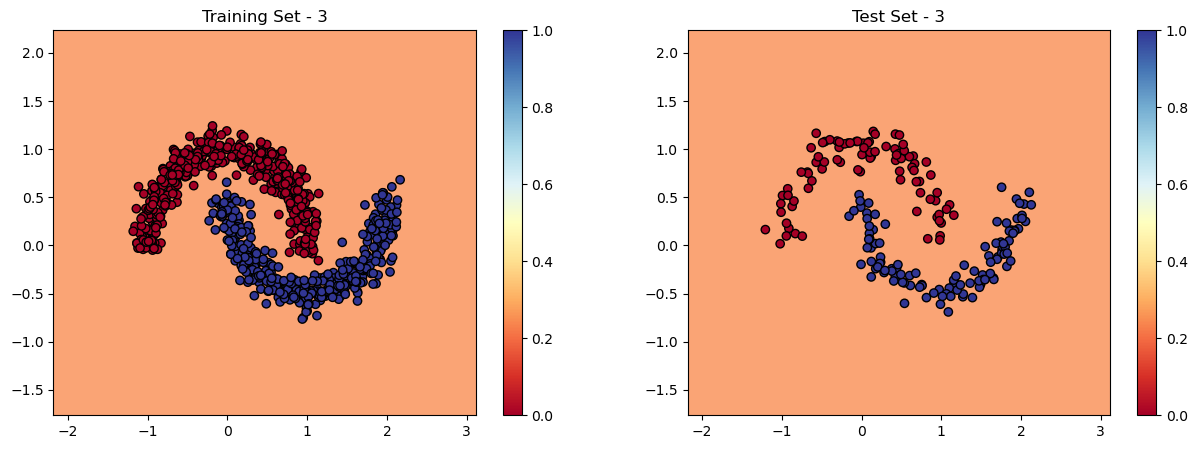

KeyboardInterrupt: 

In [8]:
# Create a meshgrid covering the feature space
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
n = len(X_train)
cmap = plt.cm.RdYlBu

running_loss = 0

for i in range(n*100):
    net.train_step(X_train[i%n], y_train[i%n])
    running_loss += net.store_loss

    if i%n == n-1:
        epoch = i//n
        acc = net.accuracy(X_test, y_test)
        print("--------------------------------------------------")
        print(f"Epoch: {epoch}")
        print(f"Loss: {net.store_loss}")
        print(f"Weight Loss: {net.weight_loss}")
        print(f"Bias Loss: {net.bias_loss}")
        print(f"Running Loss: {running_loss}")
        print(f"Accuracy: {acc}")
        running_loss = 0
        if net.store_loss < 1e-5:
            break
        # Use the forward function to predict the class of each point in the grid
        Z = net.forward(torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float())
        Z = torch.argmax(Z, axis=1)
        Z = Z.reshape(xx.shape)
        print(Z.detach().numpy().tolist())

        fig, ax = plt.subplots(1, 2, figsize=(15, 5)) 

        contour = ax[0].contourf(xx, yy, Z, alpha=0.8, cmap=cmap)
        scatter = ax[0].scatter(X_train[:, 0].detach().numpy(), X_train[:, 1].detach().numpy(), c=torch.argmax(y_train, axis=1).detach().numpy(), cmap=cmap, edgecolors='k', label="Training Set")
        fig.colorbar(scatter, ax=ax[0])

        contour = ax[1].contourf(xx, yy, Z, alpha=0.8, cmap=cmap)
        scatter = ax[1].scatter(X_test[:, 0].detach().numpy(), X_test[:, 1].detach().numpy(), c=torch.argmax(y_test, axis=1).detach().numpy(), cmap=cmap, edgecolors='k', label="Testing Set")
        fig.colorbar(scatter, ax=ax[1])

        ax[0].set_title(f"Training Set - {epoch}")
        ax[1].set_title(f"Test Set - {epoch}")

        plt.show()